# Contextual RAG retrieval benchmark

This notebook tests whether cached BridgeRNA program and contextual-gene
features improve scientist-facing sample and response retrieval. Retrieved
transcriptomic analogues do not establish a shared mechanism. BridgeRNA remains
frozen and no expensive representation is regenerated.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image
R = Path('results')
decision = json.loads((R/'summary/decision.json').read_text())
display(pd.Series(decision).to_frame('value'))

,value
decision,C. GLOBAL BASELINES ARE SUFFICIENT
best_sample_retrieval,Raw expression
best_response_retrieval,BridgeRNA global mean
contextual_response_MRR,0.432292
transparent_reranking_MRR,0.478125
global_mean_response_MRR,0.890625
recount3_contextual_reranking,unavailable
reranking_K_test,not distinct because response corpus <25
claim,"retrieved transcriptomic analogue, not mechani..."


## 1. Study-excluded sample retrieval

Every ARCHS4 query excludes candidates from its own GSE. A hit means the same
curated tissue is found within Top-k. Contextual *response* fingerprints are not
manufactured for individual samples lacking a treatment/control reference.

In [2]:
sample = pd.read_csv(R/'sample_retrieval/sample_retrieval_summary.csv')
display(sample.style.format({c:'{:.1%}' for c in ['R@1','R@5','R@10','MRR']}).hide(axis='index'))

representation,queries,R@1,R@5,R@10,MRR,median_rank
Raw expression,3272,87.8%,94.2%,95.8%,90.4%,1.000000
PCA-15165,3272,86.3%,93.0%,95.0%,89.3%,1.000000
BridgeRNA global mean,3272,82.3%,91.2%,94.0%,86.3%,1.000000
BridgeRNA layer12 mean+SD,3272,81.7%,90.6%,93.8%,85.8%,1.000000
BridgeRNA Hallmark mean+SD,3272,83.8%,91.6%,94.3%,87.5%,1.000000


## 2. Exercise-response retrieval

The contextual fingerprint is a 15,165-gene neighborhood-turnover vector, not
a giant token concatenation. Previous Axis A/B labels are not independent
ground truth because BridgeRNA contributed to their discovery; results here are
diagnostic rather than confirmatory.

representation,ground_truth,queries,R@1,R@5,R@10,MRR,median_rank
Raw expression,previous exploratory Axis A/B; not independent of BridgeRNA discovery,8,62.5%,87.5%,100.0%,74.5%,1.000000
PCA-15165,previous exploratory Axis A/B; not independent of BridgeRNA discovery,8,62.5%,87.5%,100.0%,76.6%,1.000000
BridgeRNA global mean,previous exploratory Axis A/B; not independent of BridgeRNA discovery,8,87.5%,87.5%,100.0%,89.1%,1.000000
Hallmark response fingerprint,previous exploratory Axis A/B; not independent of BridgeRNA discovery,8,12.5%,75.0%,100.0%,42.2%,2.500000
Contextual gene-response fingerprint,previous exploratory Axis A/B; not independent of BridgeRNA discovery,8,12.5%,87.5%,100.0%,43.2%,2.500000
Transparent Hallmark+context reranking,previous exploratory Axis A/B; not independent of BridgeRNA discovery,8,25.0%,75.0%,100.0%,47.8%,2.500000


,requested_K,effective_candidates,distinct_stage_test
0,25,7,False
1,50,7,False
2,100,7,False


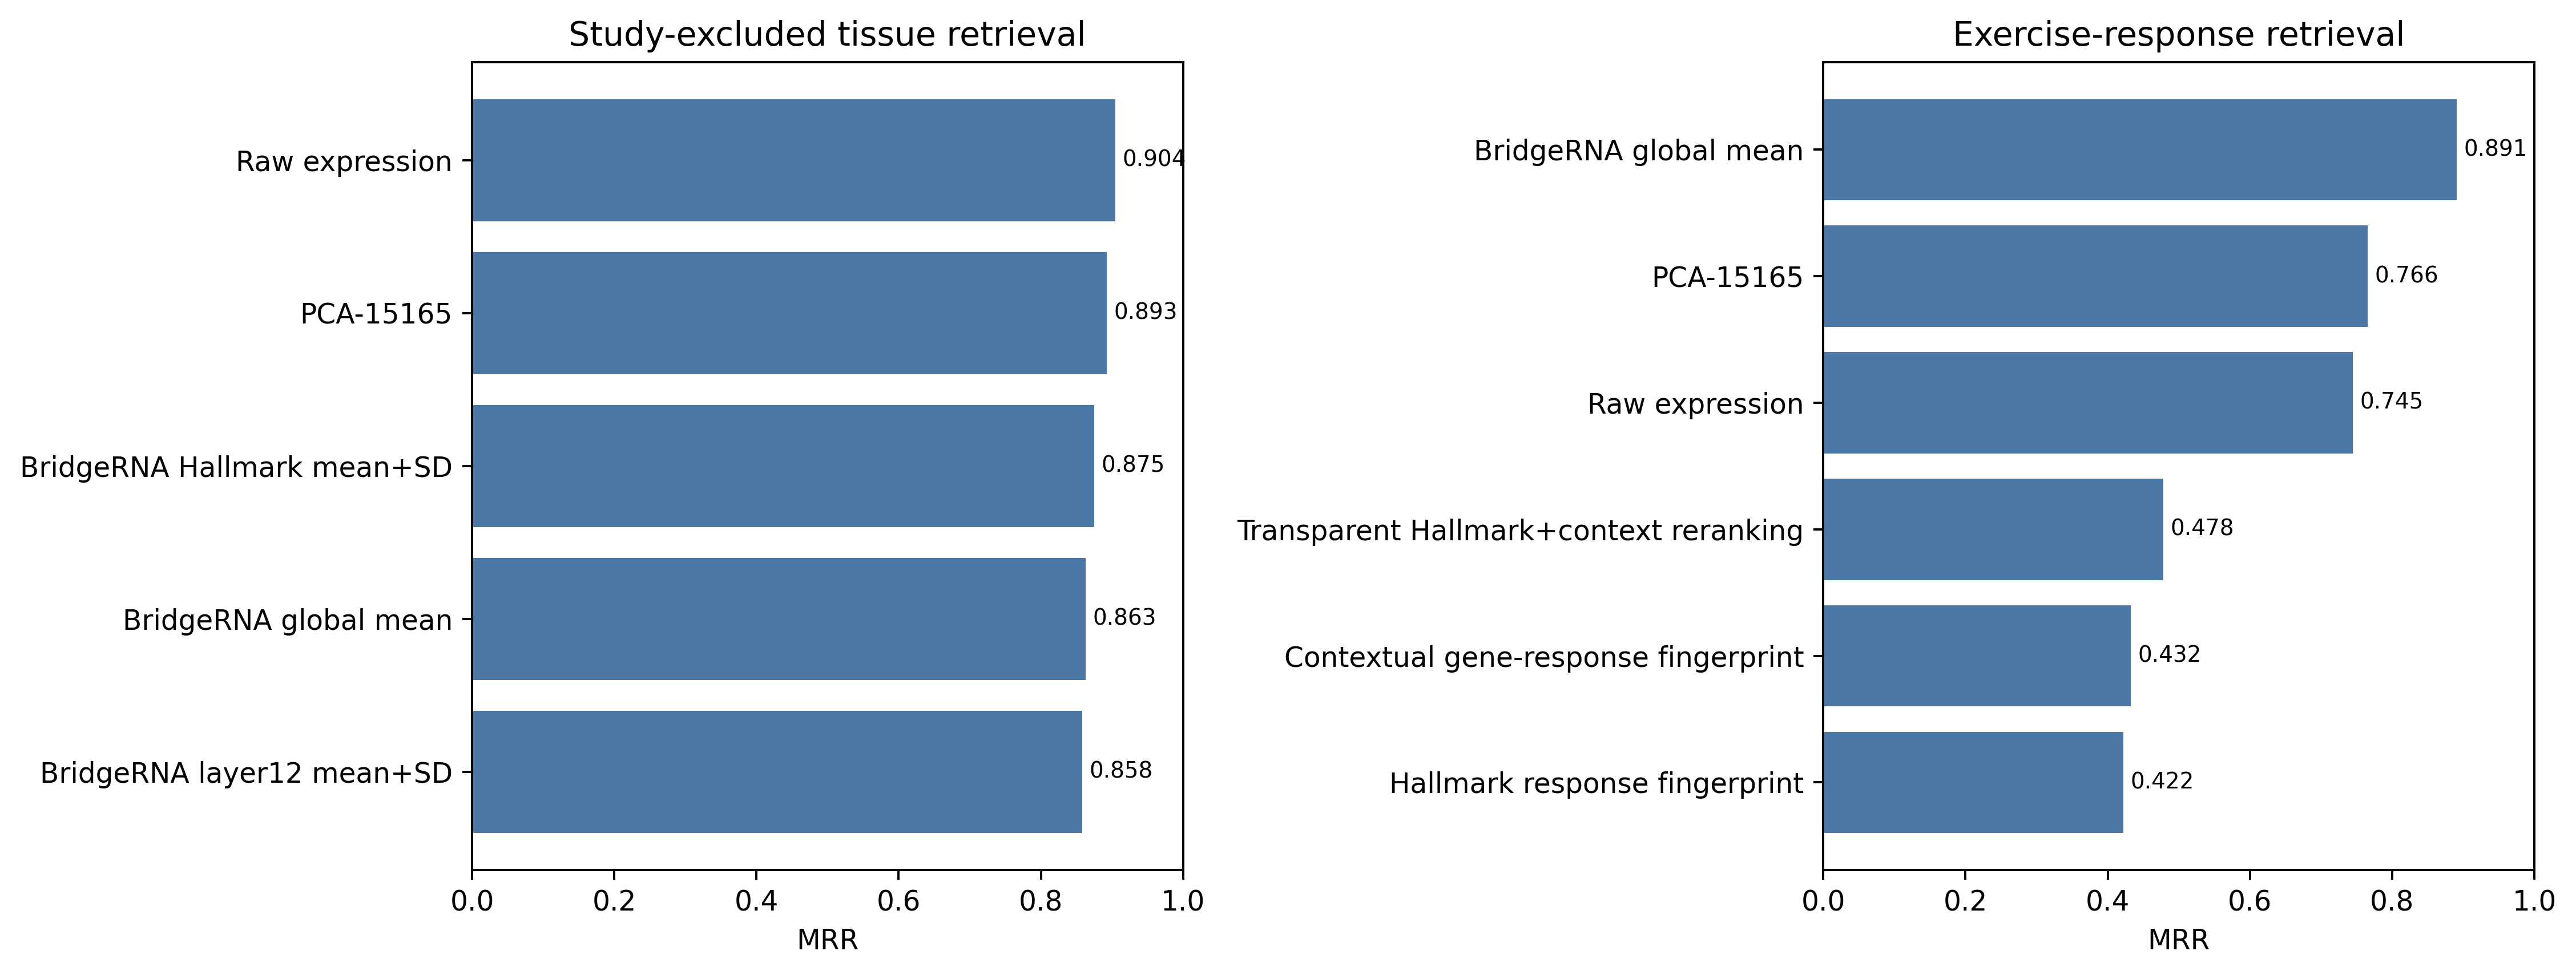

In [3]:
response = pd.read_csv(R/'response_retrieval/exercise_response_retrieval_summary.csv')
display(response.style.format({c:'{:.1%}' for c in ['R@1','R@5','R@10','MRR']}).hide(axis='index'))
display(pd.read_csv(R/'reranking/candidate_depth_audit.csv'))
display(Image(filename=str(R/'figures/retrieval_summary.png')))

## 3. Explainable contextual reranking

The transparent composite retains Hallmark and contextual similarities as
separate fields. Pathway or IG explanations are not generated unless directly
supported by saved evidence.

In [4]:
display(pd.read_csv(R/'reranking/transparent_contextual_reranking_top5.csv').head(25))

,query,rank,retrieved,composite,hallmark_similarity,context_similarity,same_exploratory_family
0,human_GSE108643,1,human_GSE71972,0.949615,0.953113,0.946117,False
1,human_GSE108643,2,human_GSE151066,0.914276,0.900746,0.927806,False
2,human_GSE108643,3,human_GSE86931,0.909518,0.885871,0.933165,True
3,human_GSE108643,4,mouse_GSE132520,0.825928,0.840480,0.811375,True
4,human_GSE108643,5,mouse_GSE126962,0.573566,0.360187,0.786945,True
5,human_GSE151066,1,human_GSE71972,0.922208,0.913743,0.930673,False
6,human_GSE151066,2,human_GSE108643,0.914276,0.900746,0.927806,False
7,human_GSE151066,3,human_GSE86931,0.908555,0.923358,0.893752,False
8,human_GSE151066,4,mouse_GSE132520,0.845479,0.902334,0.788624,False
9,human_GSE151066,5,mouse_GSE126962,0.423138,0.083983,0.762293,False


## 4. RR1/RR3 false-friend safety

Genuine RR3 technical replications should rank above the known RR1↔RR3-39 false
friend. Graph parameters were frozen before these cases were evaluated.

In [5]:
display(pd.read_csv(R/'false_friend/false_friend_safety.csv'))
display(pd.read_csv(R/'false_friend/contextual_graph_stress.csv'))

,representation,RR3_39_above_false_friend,RR3_40_above_false_friend
0,Bridge mean,False,True
1,Graph signed-edge response,True,True
2,Hallmark mean+SD,True,True
3,PCA-15165,True,True
4,Raw expression,True,True
5,Contextual kNN graph,True,True


,k,graph,comparison,signed_edge_cosine,signed_edge_correlation,edges_A,edges_B
0,10,union,RR1,0.183429,0.184914,204759,209271
1,10,union,RR3-39,0.319309,0.319231,163894,163303
2,10,union,RR3-40,0.399024,0.399005,160472,161860
3,10,union,RR1↔RR3-39 false friend,0.011796,0.011390,204759,163894


## 5. ARCHS4/recount3 and cross-species references

The established recount3 and balanced human↔mouse results are reused unchanged.
Contextual recount3 reranking is explicitly unavailable because those tokens
were not cached.

In [6]:
display(pd.read_csv(R/'technical_pairs/paired_recount3_existing_summary.csv'))
display(pd.read_csv(R/'technical_pairs/contextual_reranking_status.csv'))
display(pd.read_csv(R/'cross_species/existing_balanced_tissue_retrieval.csv').head(30))

,Search space,Queries,Expression Pearson,Expression Spearman,Paired cosine,Exact R@1,R@5,R@10,R@100,Median rank,Median percentile,Same-GSE R@1,Same-GSE R@5
0,Paired samples (562),562,0.968098,0.960116,0.999218,0.587189,0.841637,0.919929,0.998221,1.0,1.000000,0.982206,1.000000
1,"Full human ARCHS4 (510,709)",562,0.968098,0.960116,0.999218,0.284698,0.695730,0.772242,0.918149,2.0,0.999998,0.761566,0.855872


,representation,status,reason
0,contextual/Hallmark reranking,unavailable,paired recount3 contextual tokens and Hallmark...


,cohort,balance,representation,readout,direction,accuracy_mean,accuracy_sd,macro_f1_mean,macro_f1_sd,mrr_mean,mrr_sd,seeds,train_samples,test_samples
0,expanded_replicated,balanced,bridgerna,centroid_cosine,human_to_mouse,0.642593,0.054770,0.625091,0.043368,0.759394,0.033445,20,54,54
1,expanded_replicated,balanced,bridgerna,centroid_cosine,mouse_to_human,0.575926,0.048774,0.540286,0.038243,0.700236,0.033701,20,54,54
2,expanded_replicated,balanced,bridgerna,knn_cosine_k1,human_to_mouse,0.750000,0.073216,0.718275,0.076604,NaN,NaN,20,54,54
3,expanded_replicated,balanced,bridgerna,knn_cosine_k1,mouse_to_human,0.683333,0.045321,0.611701,0.041442,NaN,NaN,20,54,54
4,expanded_replicated,balanced,bridgerna,linear_softmax_probe,human_to_mouse,0.716667,0.045797,0.687546,0.043381,NaN,NaN,20,54,54
5,expanded_replicated,balanced,bridgerna,linear_softmax_probe,mouse_to_human,0.610185,0.043106,0.585515,0.035033,NaN,NaN,20,54,54
6,expanded_replicated,balanced,joint_pca,centroid_cosine,human_to_mouse,0.732407,0.021221,0.706191,0.035104,0.827962,0.015880,20,54,54
7,expanded_replicated,balanced,joint_pca,centroid_cosine,mouse_to_human,0.855556,0.037809,0.850818,0.054136,0.913198,0.021393,20,54,54
8,expanded_replicated,balanced,joint_pca,knn_cosine_k1,human_to_mouse,0.743519,0.039524,0.723304,0.040901,NaN,NaN,20,54,54
9,expanded_replicated,balanced,joint_pca,knn_cosine_k1,mouse_to_human,0.825000,0.028484,0.854058,0.030280,NaN,NaN,20,54,54


## 6. Decision

Candidate K=25/50/100 is not a distinct test because the curated response corpus
contains fewer than 25 eligible independent candidates. A contextual RAG layer
is supported only if reranking improves over PCA/global baselines while reducing
the false friend and preserving true RR3 matches.

In [7]:
display(pd.read_csv(R/'summary/decision.csv').T)

,0
decision,C. GLOBAL BASELINES ARE SUFFICIENT
best_sample_retrieval,Raw expression
best_response_retrieval,BridgeRNA global mean
contextual_response_MRR,0.432292
transparent_reranking_MRR,0.478125
global_mean_response_MRR,0.890625
recount3_contextual_reranking,unavailable
reranking_K_test,not distinct because response corpus <25
claim,"retrieved transcriptomic analogue, not mechani..."
